# Music Genre Classification

In [ ]:
!pip install librosa scikit-learn joblib matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.3.4-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached decorator-5.2.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached packaging-25.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using c

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip



   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ------------ --------------------------- 11/36 [numpy]
   ----------

In [5]:
!pip install librosa

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [ ]:
import sys
print(sys.executable)

d:\anaconda3\python.exe


In [3]:
!{sys.executable} -m pip install librosa

  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Using cached pooch-1.8.2-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl.metadata (5.6 kB)
Using cached librosa-0.11.0-py3-none-any.whl (260 kB)
Using cached audioread-3.1.0-py3-none-any.whl (23 kB)
Using cached pooch-1.8.2-py3-none-any.whl (64 kB)
Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl (1.0 MB)
Using cached soxr-1.0.0-cp312-abi3-win_amd64.whl (172 kB)

   ---------------------------------------- 0/5 [soxr]
   -------- ------------------------------- 1/5 [audioread]
   -------- ------------------------------- 1/5 [audioread]
   ---------------- ----------------------- 2/5 [soundfile]
   ---------------- ----------------------- 2/5 [soundfile]
   ------------------------ --------------- 3/5 [pooch]
   ------------------------ -


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


### Import Libraries

In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt

### Load and Extract Features

In [2]:
# Set dataset path
DATASET_PATH = 'C:\\Users\\dell\\Documents\\Music Genre Classification\\genres'

def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, duration=30)
        mfccs = np.mean(librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20).T, axis=0)
        chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr).T, axis=0)
        mel = np.mean(librosa.feature.melspectrogram(y=y, sr=sr).T, axis=0)
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr).T, axis=0)
        tonnetz = np.mean(librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr).T, axis=0)
        features = np.hstack([mfccs, chroma, mel, contrast, tonnetz])
        return features
    except Exception as e:
        print("Error processing:", file_path, e)
        return None


In [3]:
import os

DATASET_PATH = 'genres'  # the path you used before
print("Current path:", os.getcwd())
print("Folder exists:", os.path.exists(DATASET_PATH))
print("Files inside:", os.listdir(DATASET_PATH) if os.path.exists(DATASET_PATH) else "Path not found")


Current path: c:\Users\dell\Documents\Music Genre Classification
Folder exists: True
Files inside: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [4]:
import os

DATASET_PATH = r"C:\Users\dell\Documents\Music Genre Classification\genres"
print("Path exists:", os.path.exists(DATASET_PATH))

for genre in os.listdir(DATASET_PATH):
    print(genre, "->", len(os.listdir(os.path.join(DATASET_PATH, genre))), "files")


Path exists: True
blues -> 100 files
classical -> 100 files
country -> 100 files
disco -> 100 files
hiphop -> 100 files
jazz -> 100 files
metal -> 100 files
pop -> 100 files
reggae -> 100 files
rock -> 100 files


### Build Dataset from Audio Files

In [5]:
import os

genre_path = r"C:\Users\dell\Documents\Music Genre Classification\genres\blues"
print("Sample files in 'blues':")
print(os.listdir(genre_path)[:10])


Sample files in 'blues':
['blues.00000.au', 'blues.00001.au', 'blues.00002.au', 'blues.00003.au', 'blues.00004.au', 'blues.00005.au', 'blues.00006.au', 'blues.00007.au', 'blues.00008.au', 'blues.00009.au']


In [6]:
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 
          'jazz', 'metal', 'pop', 'reggae', 'rock']

features_list = []
labels = []

for genre in genres:
    genre_path = os.path.join(DATASET_PATH, genre)
    for file in os.listdir(genre_path):
        if file.endswith(('.wav', '.au')):
            file_path = os.path.join(genre_path, file)
            data = extract_features(file_path)
            if data is not None:
                features_list.append(data)
                labels.append(genre)

X = np.array(features_list)
y = np.array(labels)

print("Dataset created with shape:", X.shape)


d:\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
d:\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 45.0.0.
  "class": algorithms.Blowfish,
d:\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


Dataset created with shape: (1000, 173)


### Preprocess Data

In [7]:
# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
print("Train set:", X_train.shape, "Test set:", X_test.shape)


Train set: (800, 173) Test set: (200, 173)


### Train Random Forest Model

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.715
Classification Report:
              precision    recall  f1-score   support

       blues       0.89      0.80      0.84        20
   classical       0.86      0.95      0.90        20
     country       0.61      0.55      0.58        20
       disco       0.77      0.50      0.61        20
      hiphop       0.55      0.85      0.67        20
        jazz       0.59      0.85      0.69        20
       metal       0.85      0.85      0.85        20
         pop       0.88      0.75      0.81        20
      reggae       0.62      0.50      0.56        20
        rock       0.69      0.55      0.61        20

    accuracy                           0.71       200
   macro avg       0.73      0.71      0.71       200
weighted avg       0.73      0.71      0.71       200



### Confusion Matrix Visualization

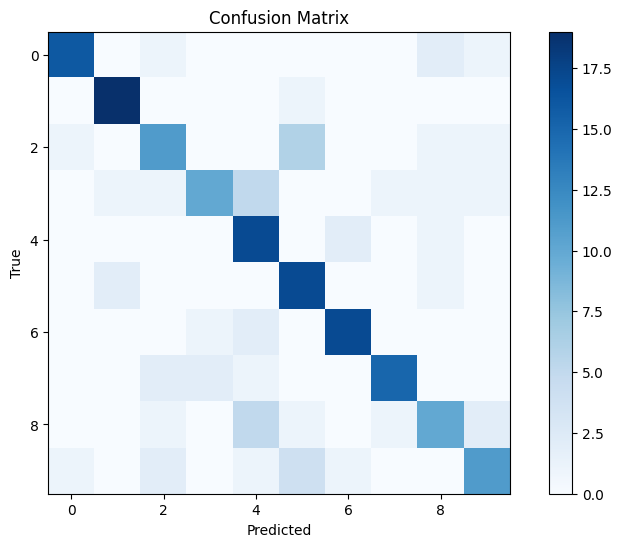

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


### Save Model and Scaler

In [10]:
joblib.dump(rf, 'music_genre_model.pkl')
joblib.dump(scaler, 'music_scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
print("Model, scaler, and label encoder saved successfully.")


Model, scaler, and label encoder saved successfully.


### Predict Genre for a New Audio File

In [14]:
def predict_genre(audio_file):
    model = joblib.load('music_genre_model.pkl')
    scaler = joblib.load('music_scaler.pkl')
    le = joblib.load('label_encoder.pkl')
    
    features = extract_features(audio_file)
    if features is not None:
        scaled_features = scaler.transform([features])
        prediction = model.predict(scaled_features)
        genre = le.inverse_transform(prediction)[0]
        print(f"Predicted Genre: {genre}")
    else:
        print("Error: Could not extract features from file.")

# Example usage:
predict_genre("C:\\Users\\dell\\Documents\\Music Genre Classification\\genres\\blues\\blues.00000.au")


Predicted Genre: blues
